# Week 4 — Task 2: Ensemble Learning — Random Forest vs. XGBoost

**Neurofive ML Track**

Goal: move beyond a single model and compare two **ensemble methods** --
Random Forest and XGBoost -- against the earlier single Logistic Regression
model on the Titanic dataset (reusing the same engineered features from the
pipeline task: `FamilySize`, `IsAlone`, `Title`).


## 1. Imports and data loading

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('titanic.csv')
df.shape

(891, 12)

## 2. Cleaning and feature engineering (same as the pipeline task)

In [2]:
df['HasCabin'] = df['Cabin'].notna().astype(int)
df['Age'] = df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df['Title'] = df['Name'].str.extract(r',\s*([^\.]*)\.')
title_map = {'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master', 'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'}
df['Title'] = df['Title'].map(title_map).fillna('Rare')

df = df.drop(columns=['Cabin'])

features = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Survived'])
target = df['Survived']

features_encoded = pd.get_dummies(features, columns=['Sex', 'Embarked', 'Title'], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, target, test_size=0.2, random_state=42, stratify=target
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 712
Test set size: 179


## 3. Baseline: single Logistic Regression model (for comparison)

In [3]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

print(f"Logistic Regression accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

Logistic Regression accuracy: 0.8212


## 4. Train a Random Forest

In [4]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(f"Random Forest accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Did Not Survive', 'Survived']))

Random Forest accuracy: 0.8268
                 precision    recall  f1-score   support

Did Not Survive       0.83      0.90      0.86       110
       Survived       0.82      0.71      0.76        69

       accuracy                           0.83       179
      macro avg       0.82      0.81      0.81       179
   weighted avg       0.83      0.83      0.82       179



## 5. Train an XGBoost model

In [5]:
xgb_model = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print(f"XGBoost accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=['Did Not Survive', 'Survived']))

XGBoost accuracy: 0.7989
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.85      0.84       110
       Survived       0.75      0.71      0.73        69

       accuracy                           0.80       179
      macro avg       0.79      0.78      0.79       179
   weighted avg       0.80      0.80      0.80       179



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:02:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## 6. Comparison table: model, metric, score

In [6]:
results = pd.DataFrame({
    'Model': ['Logistic Regression (single model)', 'Random Forest (ensemble)', 'XGBoost (ensemble)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
    ],
    'Precision (Survived)': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
    ],
    'Recall (Survived)': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
    ],
    'F1-score (Survived)': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
    ],
})
results.iloc[:, 1:] = results.iloc[:, 1:].round(4)
results

,Model,Accuracy,Precision (Survived),Recall (Survived),F1-score (Survived)
0,Logistic Regression (single model),0.8212,0.7937,0.7246,0.7576
1,Random Forest (ensemble),0.8268,0.8167,0.7101,0.7597
2,XGBoost (ensemble),0.7989,0.7538,0.7101,0.7313


## 7. Feature importances -- Random Forest vs. XGBoost

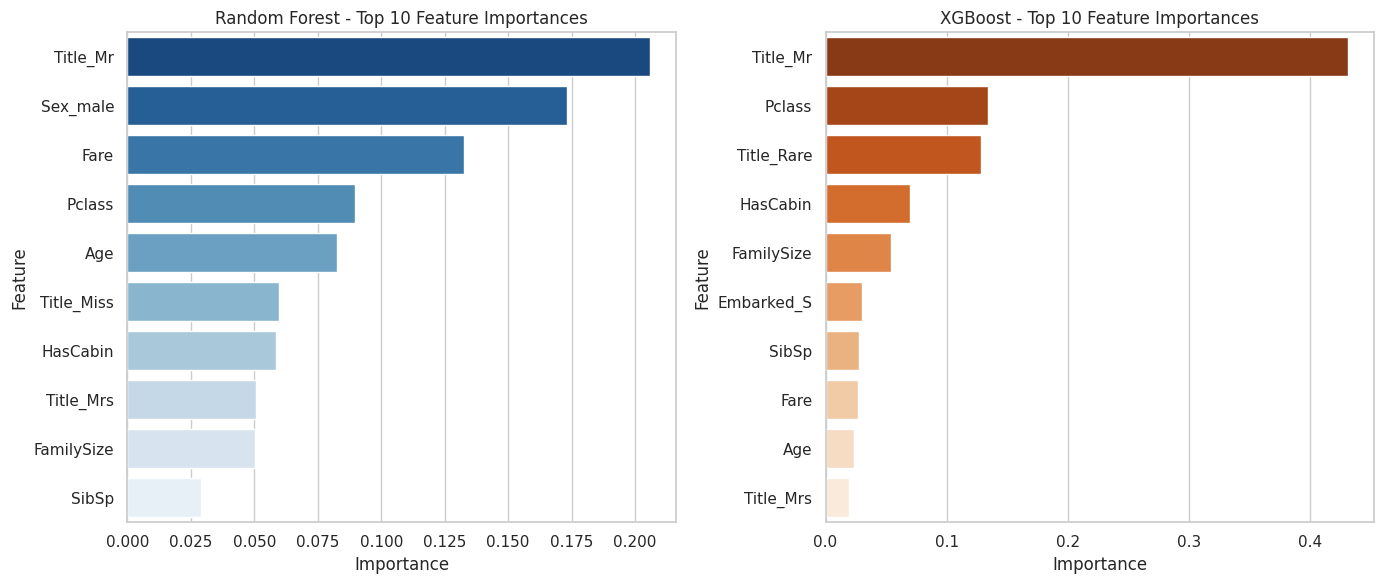

In [7]:
rf_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

xgb_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=rf_importances.head(10), y='Feature', x='Importance', hue='Feature',
            palette='Blues_r', legend=False, ax=axes[0])
axes[0].set_title('Random Forest - Top 10 Feature Importances')

sns.barplot(data=xgb_importances.head(10), y='Feature', x='Importance', hue='Feature',
            palette='Oranges_r', legend=False, ax=axes[1])
axes[1].set_title('XGBoost - Top 10 Feature Importances')

plt.tight_layout()
plt.savefig('rf_vs_xgb_feature_importances.png', bbox_inches='tight')
plt.show()

In [8]:
print("Random Forest top 5:")
print(rf_importances.head(5).to_string(index=False))
print()
print("XGBoost top 5:")
print(xgb_importances.head(5).to_string(index=False))

Random Forest top 5:
 Feature  Importance
Title_Mr    0.205763
Sex_male    0.172997
    Fare    0.132547
  Pclass    0.089686
     Age    0.082549

XGBoost top 5:
   Feature  Importance
  Title_Mr    0.431317
    Pclass    0.134204
Title_Rare    0.128606
  HasCabin    0.069943
FamilySize    0.054364


**Comparing the two rankings:** both models agree that passenger-identity
features (`Title_Mr`, `Sex_male`, `Fare`) are highly important, since these
carry most of the "women and children first" signal. Random Forest tends to
spread importance a bit more evenly across many features because it
averages over many independently-grown trees, each seeing a random subset
of features and rows. XGBoost tends to concentrate importance more sharply
on a smaller number of features, since each new tree is built specifically
to correct the errors of the previous ones and will keep leaning on
whichever features most reduce remaining error.


## 8. How Random Forest and XGBoost differ in how they combine models

**Random Forest** builds many decision trees **independently and in
parallel** -- each tree is trained on a random bootstrap sample of the rows
and only considers a random subset of features at each split. The final
prediction is simply a majority vote (classification) or average
(regression) across all the trees. This is called **bagging**, and it works
by averaging out the mistakes of individual trees, which reduces variance
and overfitting.

**XGBoost** builds trees **sequentially, one at a time**, where each new
tree is trained specifically to correct the errors made by the trees built
so far (this is called **boosting**). Rather than voting independently,
each tree adds a small, weighted correction on top of the previous
prediction. This often lets XGBoost achieve slightly higher accuracy than
Random Forest, but it can be more prone to overfitting if not carefully
tuned (e.g., with learning rate, tree depth, and number of estimators), and
it must be trained in strict sequence rather than in parallel.


## 9. Summary

- Reused the Titanic dataset with the engineered features (`FamilySize`, `IsAlone`, `Title`) from the pipeline task.
- Trained and compared three models: Logistic Regression (single model baseline), Random Forest, and XGBoost.
- Compared performance in a model/metric/score table.
- Plotted and compared feature importances side by side for the two ensemble models.
- Explained how bagging (Random Forest) and boosting (XGBoost) differ in how they combine trees.
